# Notebook 02 — Exploratory Data Analysis

Explores `data/processed/results_clean.csv` to understand patterns that inform feature engineering:
- Match volume over time
- Home advantage
- Goal distributions
- Top nations by win rate
- World Cup performance history
- Recent form of WC 2026 teams

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

PROC = Path('data/processed')
FIGS = Path('figures')
FIGS.mkdir(exist_ok=True)

df = pd.read_csv(PROC / 'results_clean.csv', parse_dates=['date'])
df['year'] = df['date'].dt.year
print(f'Loaded {len(df):,} matches ({df["year"].min()}–{df["year"].max()})')

Loaded 49,373 matches (1872–2026)


## 1. Match Volume Over Time

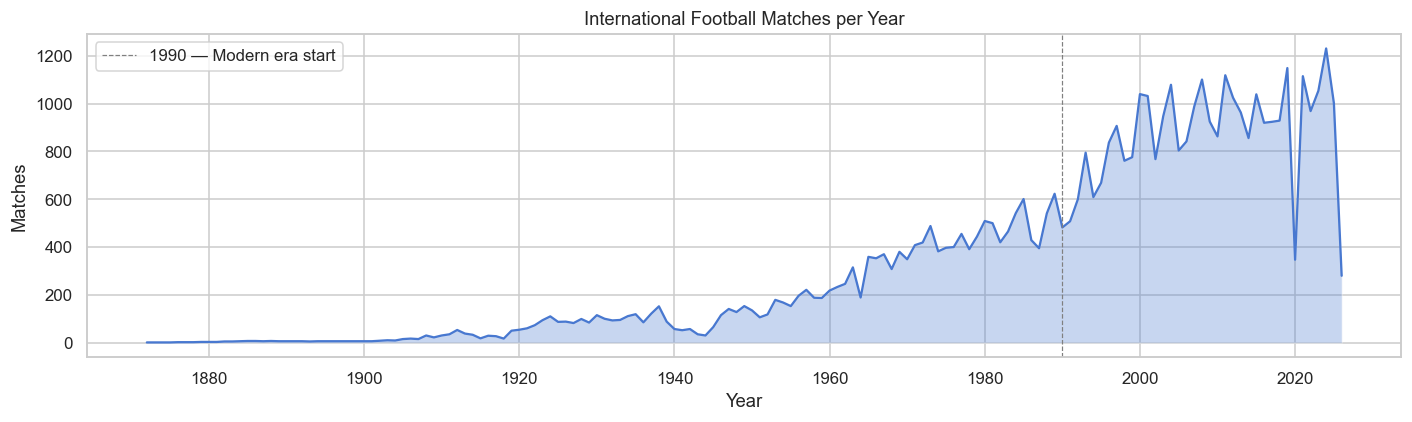

Peak year: 2024 (1231 matches)


In [2]:
matches_per_year = df.groupby('year').size()

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(matches_per_year.index, matches_per_year.values, alpha=0.3)
ax.plot(matches_per_year.index, matches_per_year.values, linewidth=1.5)
ax.axvline(1990, color='grey', linestyle='--', linewidth=0.8, label='1990 — Modern era start')
ax.set(title='International Football Matches per Year', xlabel='Year', ylabel='Matches')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / '01_matches_per_year.png')
plt.show()
print(f'Peak year: {matches_per_year.idxmax()} ({matches_per_year.max()} matches)')

## 2. Home Advantage

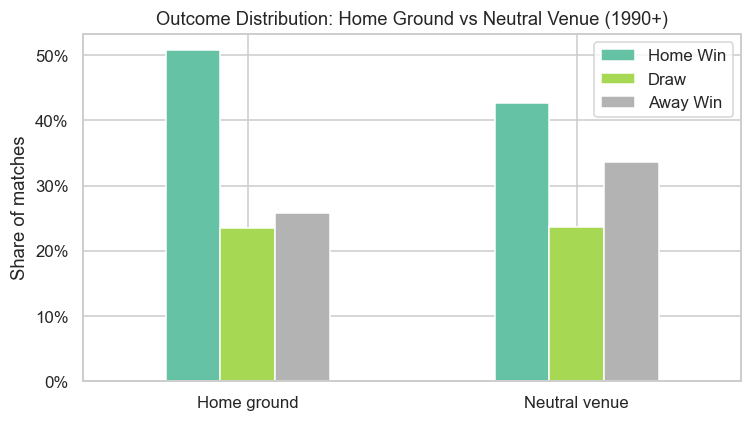

              Home Win   Draw Away Win
Home ground      50.7%  23.5%    25.8%
Neutral venue    42.7%  23.6%    33.7%


In [3]:
modern = df[df['year'] >= 1990].copy()

# Neutral vs non-neutral
home_adv = modern.groupby('neutral')['outcome'].value_counts(normalize=True).unstack()
home_adv.index = ['Home ground', 'Neutral venue']
home_adv.columns = ['Home Win', 'Draw', 'Away Win']

fig, ax = plt.subplots(figsize=(7, 4))
home_adv.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set(title='Outcome Distribution: Home Ground vs Neutral Venue (1990+)',
       xlabel='', ylabel='Share of matches')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIGS / '02_home_advantage.png')
plt.show()

print(home_adv.map(lambda x: f'{x:.1%}').to_string())

## 3. Goal Distributions

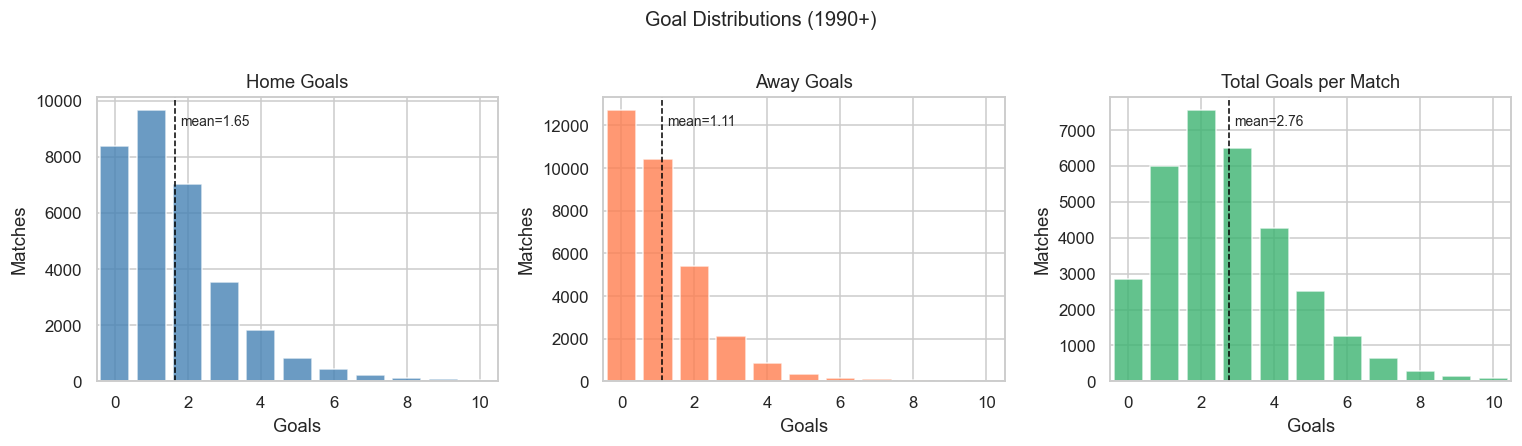

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title, color in zip(
    axes,
    ['home_score', 'away_score', 'total_goals'],
    ['Home Goals', 'Away Goals', 'Total Goals per Match'],
    ['steelblue', 'coral', 'mediumseagreen']
):
    data = modern[col]
    counts = data.value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, alpha=0.8, edgecolor='white')
    ax.set(title=title, xlabel='Goals', ylabel='Matches')
    ax.set_xlim(-0.5, 10.5)
    mu = data.mean()
    ax.axvline(mu, color='black', linestyle='--', linewidth=1)
    ax.text(mu + 0.15, ax.get_ylim()[1] * 0.9, f'mean={mu:.2f}', fontsize=9)

plt.suptitle('Goal Distributions (1990+)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / '03_goal_distributions.png')
plt.show()

## 4. Top 20 Teams by Win Rate (Competitive, 2000+)

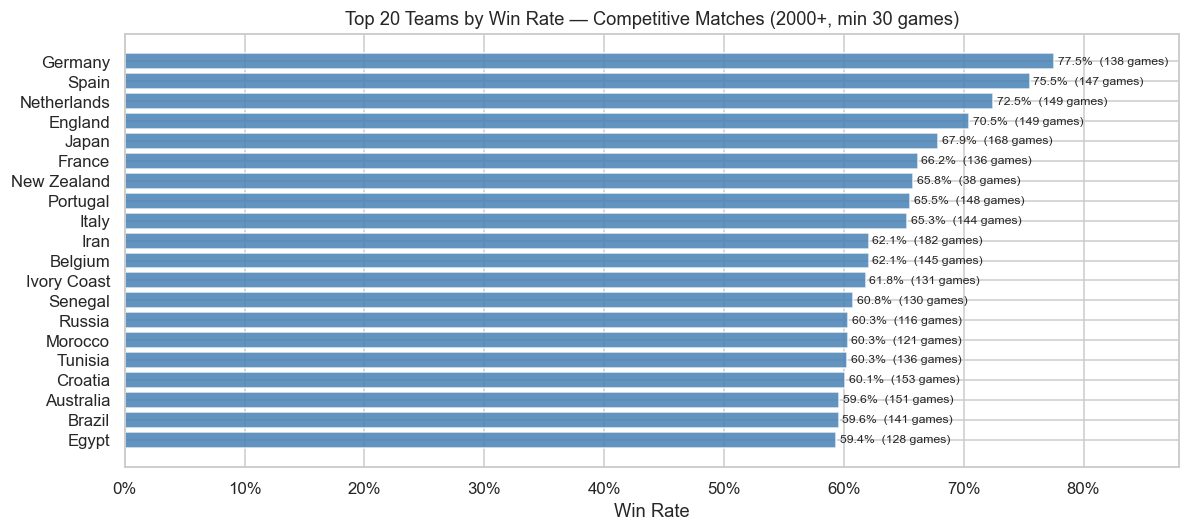

In [5]:
comp = df[(df['year'] >= 2000) & (df['is_competitive'] == 1)].copy()

# Build a team-match view: one row per team per match
home = comp[['home_team', 'outcome']].rename(columns={'home_team': 'team'})
home['win'] = (comp['outcome'] == 0).astype(int)
home['draw'] = (comp['outcome'] == 1).astype(int)
home['loss'] = (comp['outcome'] == 2).astype(int)

away = comp[['away_team', 'outcome']].rename(columns={'away_team': 'team'})
away['win']  = (comp['outcome'] == 2).astype(int)
away['draw'] = (comp['outcome'] == 1).astype(int)
away['loss'] = (comp['outcome'] == 0).astype(int)

team_df = pd.concat([home, away], ignore_index=True)
stats = team_df.groupby('team')[['win', 'draw', 'loss']].sum()
stats['matches'] = stats.sum(axis=1)
stats['win_rate'] = stats['win'] / stats['matches']
stats = stats[stats['matches'] >= 30].sort_values('win_rate', ascending=False)

top20 = stats.head(20)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top20.index[::-1], top20['win_rate'][::-1], color='steelblue', alpha=0.85)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set(title='Top 20 Teams by Win Rate — Competitive Matches (2000+, min 30 games)',
       xlabel='Win Rate')
for bar, (_, row) in zip(bars, top20[::-1].iterrows()):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{row["win_rate"]:.1%}  ({int(row["matches"])} games)',
            va='center', fontsize=8)
ax.set_xlim(0, 0.88)
plt.tight_layout()
plt.savefig(FIGS / '04_top20_win_rate.png')
plt.show()

## 5. World Cup Performance History

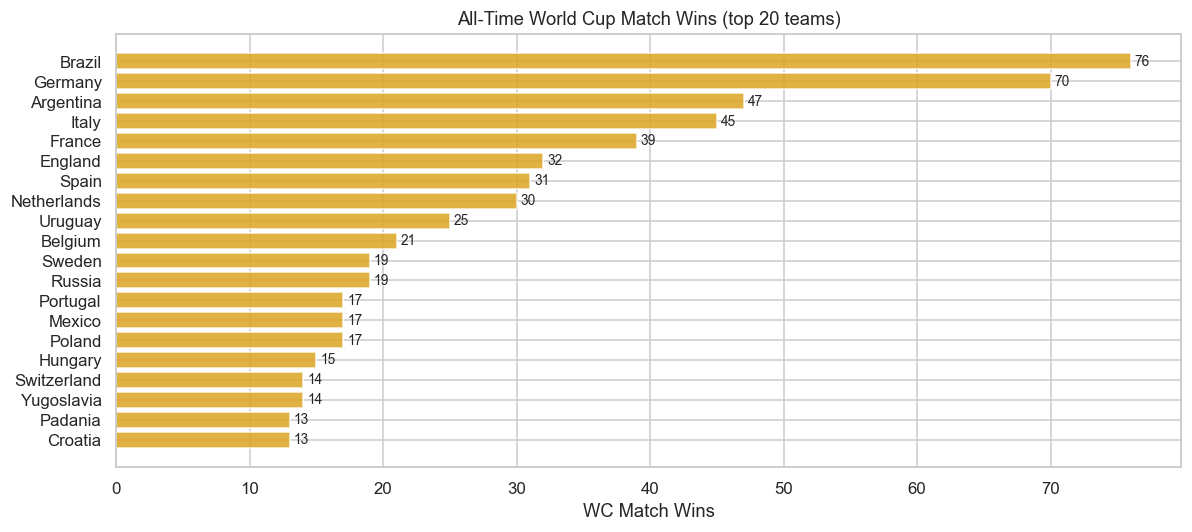

Most WC tournament appearances:
team
Brazil       22
Germany      20
Argentina    18
Italy        18
Mexico       17
France       16
Spain        16
England      16
Belgium      14
Uruguay      14


In [6]:
wc = df[df['tournament_weight'] == 5].copy()

# Win counts per team in WC matches (both sides)
wc_home = wc[wc['outcome'] == 0][['home_team']].rename(columns={'home_team': 'team'})
wc_away = wc[wc['outcome'] == 2][['away_team']].rename(columns={'away_team': 'team'})
wc_wins = pd.concat([wc_home, wc_away])['team'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(wc_wins.index[::-1], wc_wins.values[::-1], color='goldenrod', alpha=0.85)
ax.set(title='All-Time World Cup Match Wins (top 20 teams)', xlabel='WC Match Wins')
for bar, val in zip(bars, wc_wins.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / '05_wc_wins.png')
plt.show()

# WC tournaments participated per team
wc_part = pd.concat([
    wc[['year','home_team']].rename(columns={'home_team':'team'}),
    wc[['year','away_team']].rename(columns={'away_team':'team'})
]).drop_duplicates().groupby('team').size().sort_values(ascending=False)

print('Most WC tournament appearances:')
print(wc_part.head(10).to_string())

## 6. Outcome Trends Over Time

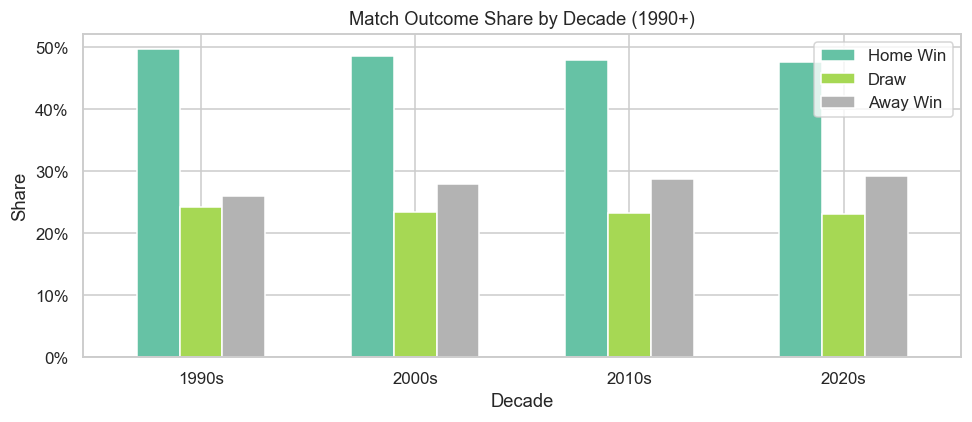

In [7]:
decade = modern.copy()
decade['decade'] = (decade['year'] // 10 * 10).astype(str) + 's'
outcome_trend = decade.groupby('decade')['outcome'].value_counts(normalize=True).unstack()
outcome_trend.columns = ['Home Win', 'Draw', 'Away Win']

fig, ax = plt.subplots(figsize=(9, 4))
outcome_trend.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set(title='Match Outcome Share by Decade (1990+)', xlabel='Decade', ylabel='Share')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIGS / '06_outcome_trends.png')
plt.show()

## 7. Recent Form of WC 2026 Teams (last 3 years)

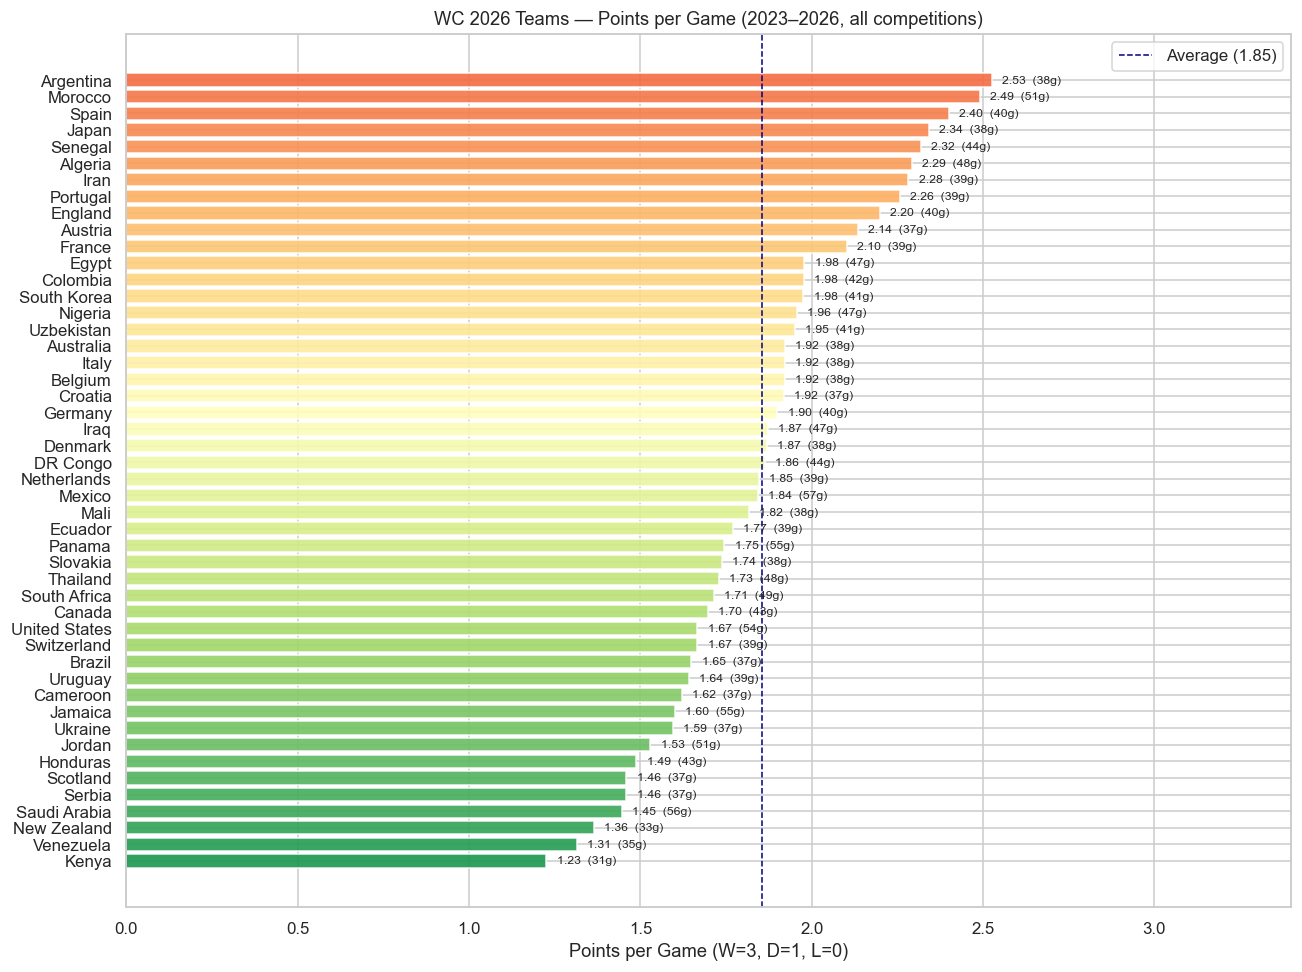

In [8]:
WC2026_TEAMS = [
    'United States', 'Mexico', 'Canada', 'Panama', 'Honduras', 'Jamaica',
    'Argentina', 'Brazil', 'Colombia', 'Ecuador', 'Uruguay', 'Venezuela',
    'Germany', 'France', 'Spain', 'England', 'Portugal', 'Netherlands',
    'Belgium', 'Italy', 'Croatia', 'Austria', 'Switzerland', 'Denmark',
    'Serbia', 'Scotland', 'Slovakia', 'Ukraine',
    'Morocco', 'Senegal', 'Egypt', 'Nigeria', 'South Africa', 'DR Congo',
    'Cameroon', 'Mali', 'Algeria',
    'Japan', 'South Korea', 'Iran', 'Australia', 'Saudi Arabia',
    'Jordan', 'Iraq', 'Uzbekistan',
    'New Zealand', 'Kenya', 'Thailand',
]

recent = df[df['year'] >= 2023].copy()

# Build team-match view for recent matches
def team_results(data):
    h = data[['home_team','outcome']].rename(columns={'home_team':'team'})
    h['win']  = (data['outcome'] == 0).values.astype(int)
    h['draw'] = (data['outcome'] == 1).values.astype(int)
    h['loss'] = (data['outcome'] == 2).values.astype(int)
    a = data[['away_team','outcome']].rename(columns={'away_team':'team'})
    a['win']  = (data['outcome'] == 2).values.astype(int)
    a['draw'] = (data['outcome'] == 1).values.astype(int)
    a['loss'] = (data['outcome'] == 0).values.astype(int)
    return pd.concat([h, a], ignore_index=True)

recent_team = team_results(recent)
recent_stats = recent_team.groupby('team')[['win','draw','loss']].sum()
recent_stats['matches'] = recent_stats.sum(axis=1)
recent_stats['win_rate'] = recent_stats['win'] / recent_stats['matches']
recent_stats['points_per_game'] = (recent_stats['win']*3 + recent_stats['draw']) / recent_stats['matches']

wc_recent = recent_stats.loc[recent_stats.index.isin(WC2026_TEAMS)].sort_values('points_per_game', ascending=False)

fig, ax = plt.subplots(figsize=(12, 9))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(wc_recent)))
bars = ax.barh(wc_recent.index[::-1], wc_recent['points_per_game'][::-1],
               color=colors[::-1], alpha=0.9)
ax.axvline(wc_recent['points_per_game'].mean(), color='navy', linestyle='--',
           linewidth=1, label=f'Average ({wc_recent["points_per_game"].mean():.2f})')
ax.set(title='WC 2026 Teams — Points per Game (2023–2026, all competitions)',
       xlabel='Points per Game (W=3, D=1, L=0)')
for bar, (_, row) in zip(bars, wc_recent[::-1].iterrows()):
    ax.text(bar.get_width() + 0.03,
            bar.get_y() + bar.get_height()/2,
            f'{row["points_per_game"]:.2f}  ({int(row["matches"])}g)',
            va='center', fontsize=8)
ax.set_xlim(0, 3.4)
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / '07_wc2026_recent_form.png')
plt.show()

## 8. Key Takeaways

In [9]:
comp_modern = df[(df['year'] >= 1990) & (df['is_competitive'] == 1)]
home_wr  = (comp_modern['outcome'] == 0).mean()
draw_rate = (comp_modern['outcome'] == 1).mean()
away_wr  = (comp_modern['outcome'] == 2).mean()
avg_goals = comp_modern['total_goals'].mean()

sep = '=' * 52
print(sep)
print('  EDA KEY TAKEAWAYS  (competitive matches, 1990+)')
print(sep)
print(f'  Home win rate    : {home_wr:.1%}')
print(f'  Draw rate        : {draw_rate:.1%}')
print(f'  Away win rate    : {away_wr:.1%}')
print(f'  Avg goals/match  : {avg_goals:.2f}')
print(f'  Total matches    : {len(comp_modern):,}')
print(sep)
print('  Top 5 WC 2026 teams by recent form:')
for team, row in wc_recent.head(5).iterrows():
    print(f'    {team:<20s}  {row["points_per_game"]:.2f} pts/game')
print(sep)

  EDA KEY TAKEAWAYS  (competitive matches, 1990+)
  Home win rate    : 50.2%
  Draw rate        : 20.9%
  Away win rate    : 28.9%
  Avg goals/match  : 2.85
  Total matches    : 13,419
  Top 5 WC 2026 teams by recent form:
    Argentina             2.53 pts/game
    Morocco               2.49 pts/game
    Spain                 2.40 pts/game
    Japan                 2.34 pts/game
    Senegal               2.32 pts/game
